<a href="https://colab.research.google.com/github/DylanMCullifer/NetworkScienceProject/blob/main/Final_Project_NS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing Congressional Political Polarization 2018-2022

Dylan Cullifer

Nicholas Jacob


## Sentence Transformer

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random, time
import sklearn
import scipy
import pandas as pd
import networkx.algorithms.community as co
from sentence_transformers import SentenceTransformer

# Read in all the data for the candidates
biographical_narratives = pd.read_csv("https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/biographical_narratives.csv")
policy_platforms = pd.read_csv("https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/policy_platforms.csv")
policy_platforms_aggregated = pd.read_csv("https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/policy_platforms_aggregated.csv")

merge_cols = ["candidate_webname","state_postal","cd","year","cand_party"]

# drop all entries that lack key values needed
clean_bio = biographical_narratives.dropna(subset=merge_cols)
clean_policy = policy_platforms.dropna(subset=merge_cols)
clean_policy_agg = policy_platforms_aggregated.dropna(subset=merge_cols)

# removed weird starting index column that isn't needed
clean_bio = clean_bio.drop(clean_bio.columns[0], axis=1)
clean_policy = clean_policy.drop(clean_policy.columns[0], axis=1)

# these cols appear in both but are the same so I drop them for an easy merge
drop_duplicate_cols = ["primary_type","dem_prez_vote","inc","quality_cand","win_primary","primary_pct","win_general","general_pct","FECCandID","BIOGUIDE_id"]
bio_no_dups = clean_bio.drop(columns=drop_duplicate_cols)

all_data = clean_policy.merge(bio_no_dups, on=merge_cols, how="left").merge(clean_policy_agg, on=merge_cols, how="left")

# Condenses data to one candidate row per year with their multiple stances in that year put into a set
varying_cols = all_data.groupby(merge_cols).nunique().gt(1).any()
varying_columns = varying_cols[varying_cols].index.to_list()

consistent_cols = [col for col in all_data.columns if col not in merge_cols and col not in varying_columns]
combined_dict = {col: "first" for col in consistent_cols}
combined_dict.update({col: lambda x: set(x) for col in varying_columns})

all_data = all_data.groupby(merge_cols, as_index=False).agg(combined_dict)

print("Total Candidate data shape:", all_data.shape)

# split data as needed by year and fix indexs since they transfer from the full set somehow
all_data_2018 = all_data[all_data["year"] == 2018]
all_data_2020 = all_data[all_data["year"] == 2020]
all_data_2022 = all_data[all_data["year"] == 2022]

all_data_2018 = all_data_2018.reset_index(drop=True)
all_data_2020 = all_data_2020.reset_index(drop=True)
all_data_2022 = all_data_2022.reset_index(drop=True)

print("2018 Candidate data shape:", all_data_2018.shape)
print("2020 Candidate data shape:", all_data_2020.shape)
print("2022 Candidate data shape:", all_data_2022.shape)

all_data_2020.head()

Total Candidate data shape: (4507, 23)
2018 Candidate data shape: (1499, 23)
2020 Candidate data shape: (1449, 23)
2022 Candidate data shape: (1559, 23)


,candidate_webname,state_postal,cd,year,cand_party,primary_type,dem_prez_vote,inc,quality_cand,win_primary,...,housegov_issue,FECCandID,BIOGUIDE_id,biography_text,housegov_bio,platform_text,issue_header,issue_text,policy_code,statement_id
0,Aaron Godfrey,OH,16,2020,Democrat,Open Primary,42.2,0,0,1,...,0,H8OH16090,None,One of three children in a working-class famil...,0.0,Healthcare: Despite the progress made under th...,"{Healthcare, Protecting our Parks, Fracking, L...",{As a long-time volunteer at a local animal sh...,"{Energy and Environment, Healthcare, Social We...","{15648, 15649, 15650, 15651, 15652, 15653, 156..."
1,Aaron Hermes,TX,22,2020,Republican,Open Primary,48.9,0,0,0,...,0,H0TX22328,None,MY BACKGROUND\r\r\n-Early Years \r\r\n\r\r\nI ...,0.0,'-Election Integrity: The technology and syste...,"{'-The Big Media Complex, '-Supporting Our Tro...",{When the income tax was created a little over...,"{Energy and Environment, Healthcare, Crime, So...","{18187, 18188, 18189, 18190, 18191, 18192, 181..."
2,Aaron Scanlan,FL,21,2020,Republican,Closed Primary,58.2,0,0,0,...,0,H0FL21060,None,Aaron Scanlan is a principled conservative wit...,0.0,ECONOMIC DEVELOPMENT: While our economy now is...,"{HEALTHCARE, IMMIGRATION, ECONOMIC DEVELOPMENT...",{Secure our borders and ensure the immigration...,"{Energy and Environment, Healthcare, Immigrati...","{38040, 38037, 38038, 38039}"
3,Aaron Swisher,ID,2,2020,Democrat,Partially-Closed,36.6,0,0,1,...,0,H8ID02148,None,Aaron Swisher was born and raised in rural Wes...,0.0,MANAGING AND BALANCING THE FEDERAL BUDGET: Bec...,{BOOSTING TRADE AND INCREASING IDAHO AGRICULTU...,{Idaho needs a Congressman that will fight to ...,"{Energy and Environment, Healthcare, Economics...","{41602, 41603, 41604, 41605, 41606, 41607, 416..."
4,Abby Finkenauer,IA,1,2020,Democrat,Open Primary,47.4,1,2,1,...,0,H8IA01094,None,Meet Abby\r\r\n\r\r\nAs the youngest woman eve...,0.0,Creating Jobs and a Strong Economy: As your re...,"{Standing with Our Veterans, Expanding Access ...",{We must invest in our deteriorating and under...,"{Energy and Environment, Healthcare, Social We...","{13631, 13632, 13633, 13634, 13635, 13636, 136..."


Here we load the csv data into frames for ease of handling. Each of the datasets where merged into a main set with all relavent data with duplicates across them dropped. Then all entries from a candidate from a given year are collapsed into one entry for that year where columns that don't change are one value and columns that do are a set of all their values.

In [ ]:
# grab all platform text from all candidates in a certain year
platform_text_2018 = all_data_2018["platform_text"].to_list()
platform_text_2020 = all_data_2020["platform_text"].to_list()
platform_text_2022 = all_data_2022["platform_text"].to_list()

transformer = SentenceTransformer("all-MiniLM-L6-v2")

# turn all stated platforms of each candidate into embeddings so we can compare them
platform_text_embeddings_2018 = transformer.encode(platform_text_2018, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
platform_text_embeddings_2020 = transformer.encode(platform_text_2020, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
platform_text_embeddings_2022 = transformer.encode(platform_text_2022, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)

Batches: 100%|██████████| 49/49 [00:26<00:00,  1.83it/s]


Using a sentence transformer we can take text and turn each stated platform in a an embedding that represents the meaning. Using these embeddings we can compare all the candidates based their similarity of these embeddings.

I've added a way to save these and then load them as the computation time was too long for my liking.

In [8]:
# np.save('/embedding_file_2018.npy',platform_text_embeddings_2018)
# np.save('/embedding_file_2020.npy',platform_text_embeddings_2020)
# np.save('/embedding_file_2022.npy',platform_text_embeddings_2022)

You can now load these back (or instead of running the above.

## Skip Sentence Transformer

In [9]:
import requests
import numpy as np
import tempfile
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random, time
import sklearn
import scipy
import pandas as pd

l = ["embedding_file_2018.npy","embedding_file_2020.npy","embedding_file_2022.npy"]
urlstub = "https://github.com/nurfnick/NetworkScience/raw/refs/heads/main/Project/"
platform_text_embeddings = []

for file in l:
  url = urlstub + file
  with tempfile.NamedTemporaryFile(delete=True) as temp_file:
    response = requests.get(url, stream=True)
    response.raise_for_status() # Raise an exception for bad status codes
    for chunk in response.iter_content(chunk_size=8192):
      temp_file.write(chunk)
    temp_file.seek(0) # Rewind to the beginning of the file AFTER all chunks are written
    platform_text_embeddings.append(np.load(temp_file)) # Load the array once the file is complete

platform_text_embeddings_2018 = platform_text_embeddings[0]
platform_text_embeddings_2020 = platform_text_embeddings[1]
platform_text_embeddings_2022 = platform_text_embeddings[2]

In [10]:
platform_text_embeddings_2018

array([[-0.03721941,  0.04184014,  0.07115123, ..., -0.06016336,
         0.05189839,  0.04797601],
       [ 0.03626484,  0.0238889 , -0.0512529 , ...,  0.04168224,
         0.05377446,  0.04932696],
       [ 0.01164877, -0.04022797,  0.08239871, ...,  0.04645431,
        -0.1267153 ,  0.00392156],
       ...,
       [-0.00211374,  0.07471664,  0.01043453, ..., -0.08811932,
         0.03625819,  0.07383206],
       [-0.01461367, -0.02094346, -0.01934274, ...,  0.00774604,
         0.00519193, -0.04172401],
       [-0.04477266,  0.00375577,  0.00076316, ..., -0.01743081,
         0.02402168,  0.00046611]], shape=(1499, 384), dtype=float32)

## Graph Creation

In [ ]:
sim_scores_2018 = sklearn.metrics.pairwise.cosine_similarity(platform_text_embeddings_2018)
sim_scores_2020 = sklearn.metrics.pairwise.cosine_similarity(platform_text_embeddings_2020)
sim_scores_2022 = sklearn.metrics.pairwise.cosine_similarity(platform_text_embeddings_2022)

sim_score_threshold = 0.67

G_2018 = nx.Graph()
G_2020 = nx.Graph()
G_2022 = nx.Graph()

# build graphs based on data from each year
def build_graph(sim, data, graph):
    for index, row in data.iterrows():
        # add attributes for assoritivity studies in the future
        graph.add_node(index,
         candidate_webname=row["candidate_webname"], cand_party=row["cand_party"], state_postal=row["state_postal"],
         cd=row["cd"], inc=row["inc"], primary_type=row["primary_type"])

    # add edges between nodes if their cos sim score of there platform embeddings meet a threshold
    for x in range(0, sim.shape[0]):
        sim_row = sim[x]
        sim_row[x] = 0
        all_rows = sim_row.argsort()
        # for y in range(x + 1, sim.shape[0]):
        for y in all_rows:
            edge_weight = sim[x,y]
            if edge_weight >= sim_score_threshold:
                graph.add_edge(x, y, weight=edge_weight)

    return graph

G_2018 = build_graph(sim_scores_2018, all_data_2018, G_2018)
G_2020 = build_graph(sim_scores_2020, all_data_2020, G_2020)
G_2022 = build_graph(sim_scores_2022, all_data_2022, G_2022)

print("Num Nodes 2018:", len(G_2018.nodes))
print("Num Edges 2018:", len(G_2018.edges))
print()
print("Num Nodes 2020:", len(G_2020.nodes))
print("Num Edges 2020:", len(G_2020.edges))
print()
print("Num Nodes 2022:", len(G_2022.nodes))
print("Num Edges 2022:", len(G_2022.edges))

Num Nodes 2018: 1499
Num Edges 2018: 7426

Num Nodes 2020: 1449
Num Edges 2020: 4977

Num Nodes 2022: 1559
Num Edges 2022: 3375


Graphs are made based by adding all candidates then adding edges if their embeddings are similar enough.

2018 Similarity Graph:
Number of Nodes: 1499
Number of Edges: 7426


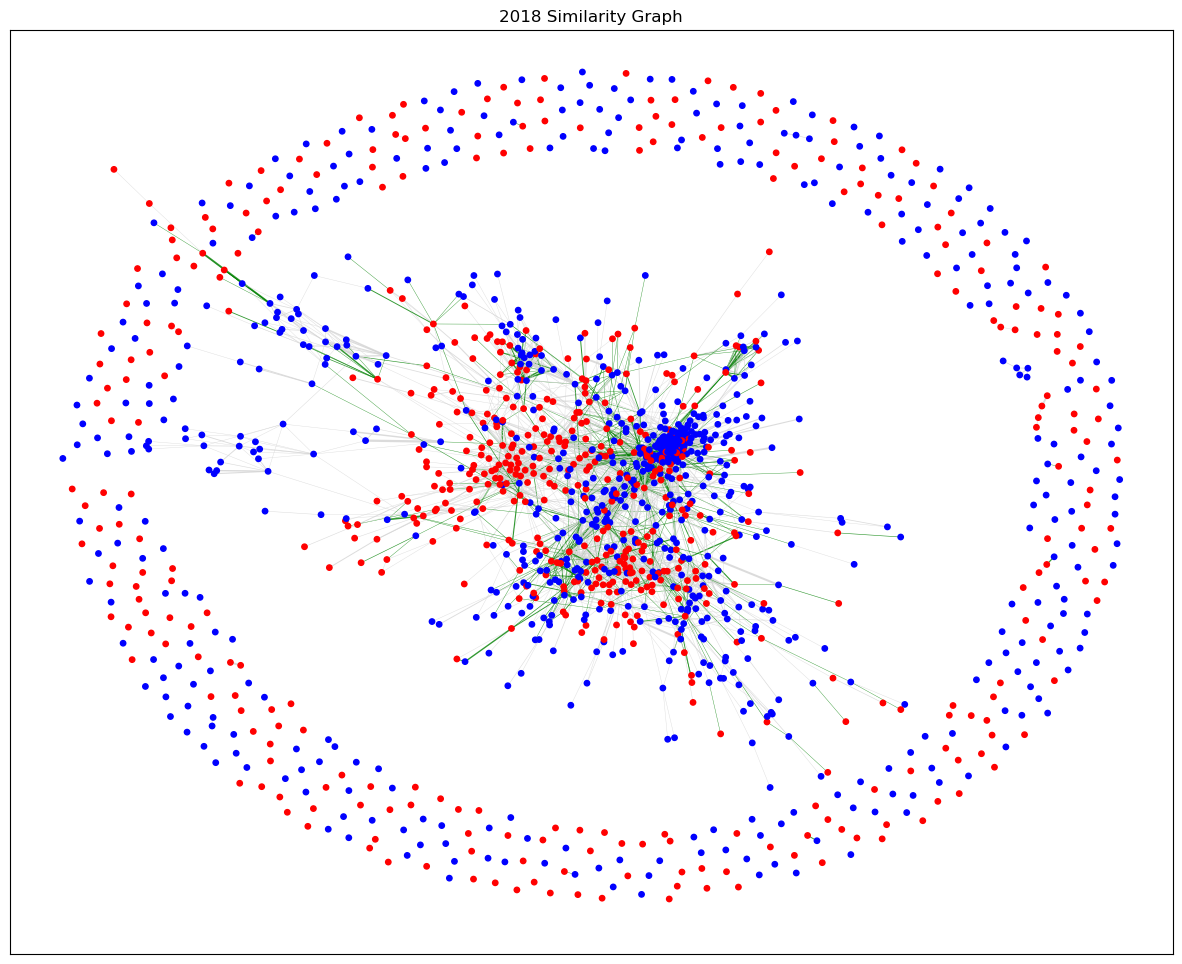

Most Similar Candidates:
Dems: John Russell / Michael Milisits
Reps: Bob Corlew / Hank Hamblin

2018 LCC Similarity Graph:
Number of Nodes: 974
Number of Edges: 7394


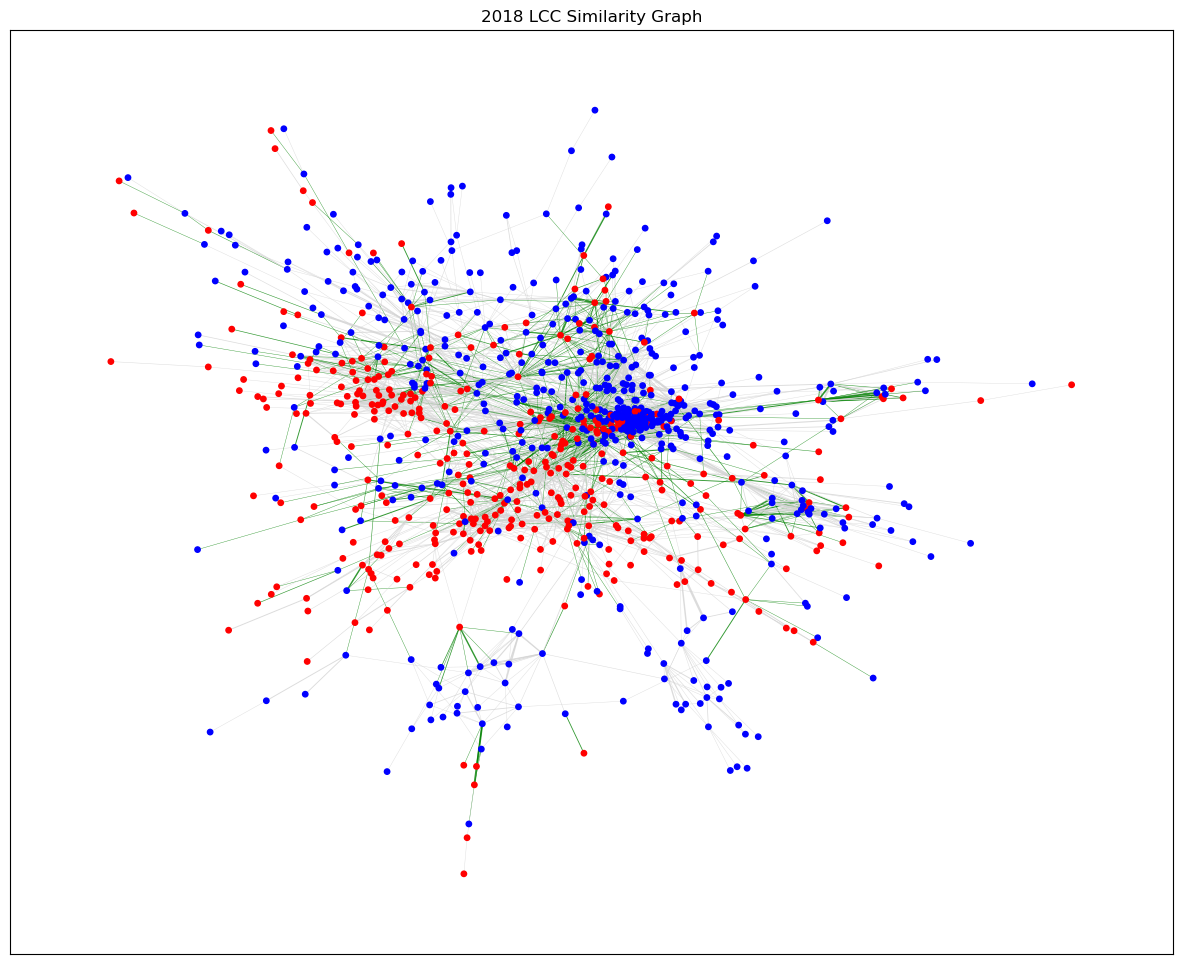

Most Similar Candidates:
Dems: John Russell / Michael Milisits
Reps: Bob Corlew / Hank Hamblin



In [ ]:
# reusable fucntion to make the graphs visual
def create_graph(graph, title):
    # party colors
    colors = {"Republican": "red", "Democrat": "blue"}

    # loop through the nodes and apply their party affiliation
    colors_nodes = []
    for entry in graph.nodes():
        cand_party = graph.nodes[entry].get("cand_party")
        if(cand_party != None):
            colors_nodes.append(colors[cand_party])
        else:
            colors_nodes.append("gray")

    all_edges = graph.edges(data=True)

    # holders for edges widths and colors
    edge_sizes = []
    color_edges = []
    max_dem_sim = 0
    max_rep_sim = 0
    # Holders for most alike candidates based on their platform text on a graph
    dem_node = (None, None, None)
    rep_node = (None, None, None)

    # loop through edges and apply colors and weights 
    for node1, node2, sim in all_edges:
        edge_sim_value = sim.get("weight", 0)
        # add width based on the similarity
        edge_size = max(0.4, (edge_sim_value - sim_score_threshold) * 10)
        edge_sizes.append(edge_size)

        # add colors and track most similiar
        if(graph.nodes[node1].get("cand_party") == graph.nodes[node2].get("cand_party")):
            color_edges.append("lightgrey")
            if(graph.nodes[node1].get("cand_party") == "Democrat" and edge_sim_value > max_dem_sim):
                max_dem_sim = edge_sim_value
                dem_node = (node1, node2, edge_sim_value)
            elif(graph.nodes[node1].get("cand_party") == "Republican" and edge_sim_value > max_rep_sim):
                max_rep_sim = edge_sim_value
                rep_node = (node1, node2, edge_sim_value)
        else:
            color_edges.append("green")

    # general graph metrics that may be useful
    top_sims = []
    top_sims.append(dem_node)
    top_sims.append(rep_node)

    print(title + ":")
    print("Number of Nodes:", len(graph.nodes()))
    print("Number of Edges:", len(graph.edges()))

    plt.close("all")
    plt.figure(figsize=(15,12))
    position = nx.spring_layout(graph, seed=1, k=2, iterations=100, scale=5, weight="weight")
    # position = nx.kamada_kawai_layout(graph, weight="weight")
    nx.draw_networkx_nodes(graph, pos=position, node_color=colors_nodes, node_size=15)
    nx.draw_networkx_edges(graph, pos=position, alpha=.8, width=edge_sizes, edge_color=color_edges)
    plt.title(title)
    plt.show()

    return top_sims
    
# fucntion to just extract names and platform text for comparsion
def get_candidate_platform_text(most_sim, graph, dataFrame):
    cand_names = []
    most_sim_platform_text = []
    cand_names.append(graph.nodes[most_sim[0][0]].get("candidate_webname"))
    cand_names.append(graph.nodes[most_sim[0][1]].get("candidate_webname"))

    cand_names.append(graph.nodes[most_sim[1][0]].get("candidate_webname"))
    cand_names.append(graph.nodes[most_sim[1][1]].get("candidate_webname"))
    for entry in cand_names:
        most_sim_platform_text.append(dataFrame.loc[dataFrame["candidate_webname"] == entry, "platform_text"].iloc[0])
    
    return most_sim_platform_text, cand_names


In [ ]:
# full graph 2018
most_sim_2018 = create_graph(G_2018, "2018 Similarity Graph")
most_sim_text_2018, most_sim_names_2018 = get_candidate_platform_text(most_sim_2018, G_2018, all_data_2018)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2018[0], "/",  most_sim_names_2018[1])
print("Reps:", most_sim_names_2018[2], "/",  most_sim_names_2018[3])
print()

# LCC graph 2018
components_2018 = nx.connected_components(G_2018)
G_2018_LCC = G_2018.subgraph(max(components_2018, key=len)).copy()

most_sim_2018_LCC = create_graph(G_2018_LCC, "2018 LCC Similarity Graph")
most_sim_text_2018_LCC, most_sim_names_2018_LCC = get_candidate_platform_text(most_sim_2018_LCC, G_2018_LCC, all_data_2018)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2018_LCC[0], "/",  most_sim_names_2018_LCC[1])
print("Reps:", most_sim_names_2018_LCC[2], "/",  most_sim_names_2018_LCC[3])
print("\n")

2020 Similarity Graph:
Number of Nodes: 1449
Number of Edges: 4977


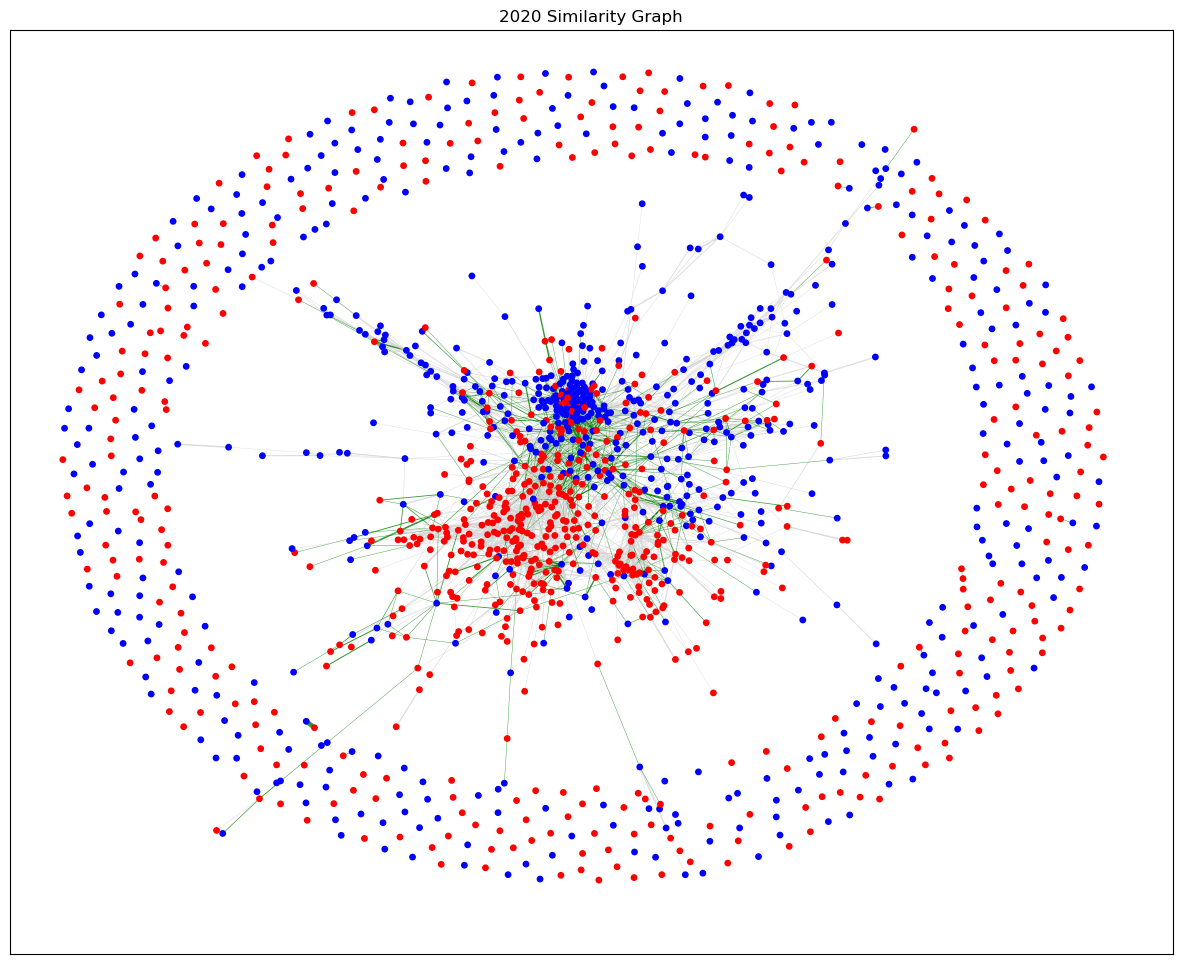

Most Similar Candidates:
Dems: Ricardo De La Fuente / Ricardo De La Fuente
Reps: Bob Latta / Glenn Grothman

2020 LCC Similarity Graph:
Number of Nodes: 867
Number of Edges: 4950


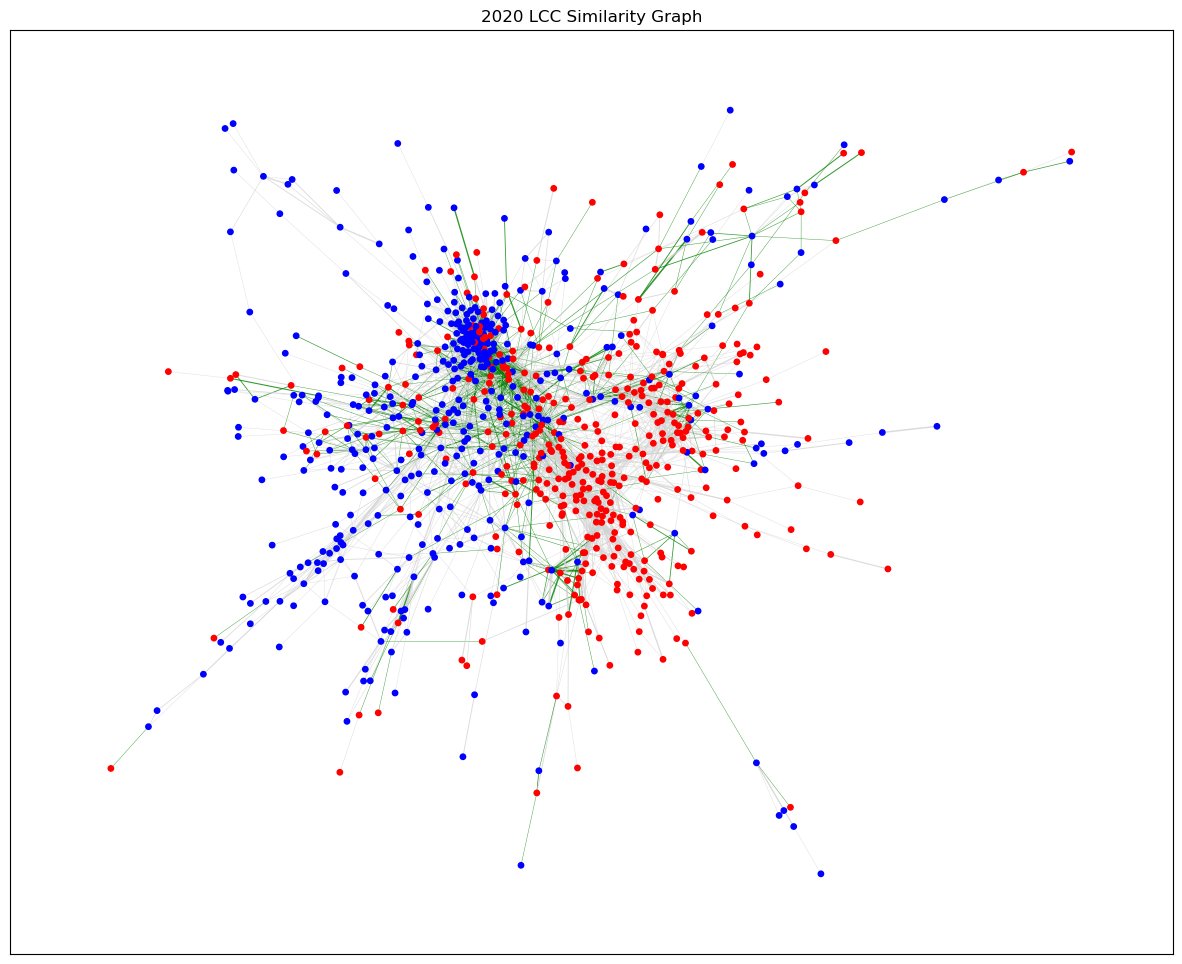

Most Similar Candidates:
Dems: Ricardo De La Fuente / Ricardo De La Fuente
Reps: Bob Latta / Glenn Grothman




In [177]:
# full graph 2020
most_sim_2020 = create_graph(G_2020, "2020 Similarity Graph")
most_sim_text_2020, most_sim_names_2020 = get_candidate_platform_text(most_sim_2020, G_2020, all_data_2020)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2020[0], "/",  most_sim_names_2020[1])
print("Reps:", most_sim_names_2020[2], "/",  most_sim_names_2020[3])
print()

# LCC graph 2020
components_2020 = nx.connected_components(G_2020)
G_2020_LCC = G_2020.subgraph(max(components_2020, key=len)).copy()

most_sim_2020_LCC = create_graph(G_2020_LCC, "2020 LCC Similarity Graph")
most_sim_text_2020_LCC, most_sim_names_2020_LCC = get_candidate_platform_text(most_sim_2020_LCC, G_2020_LCC, all_data_2020)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2020_LCC[0], "/",  most_sim_names_2020_LCC[1])
print("Reps:", most_sim_names_2020_LCC[2], "/",  most_sim_names_2020_LCC[3])
print("\n")

2022 Similarity Graph:
Number of Nodes: 1559
Number of Edges: 3375


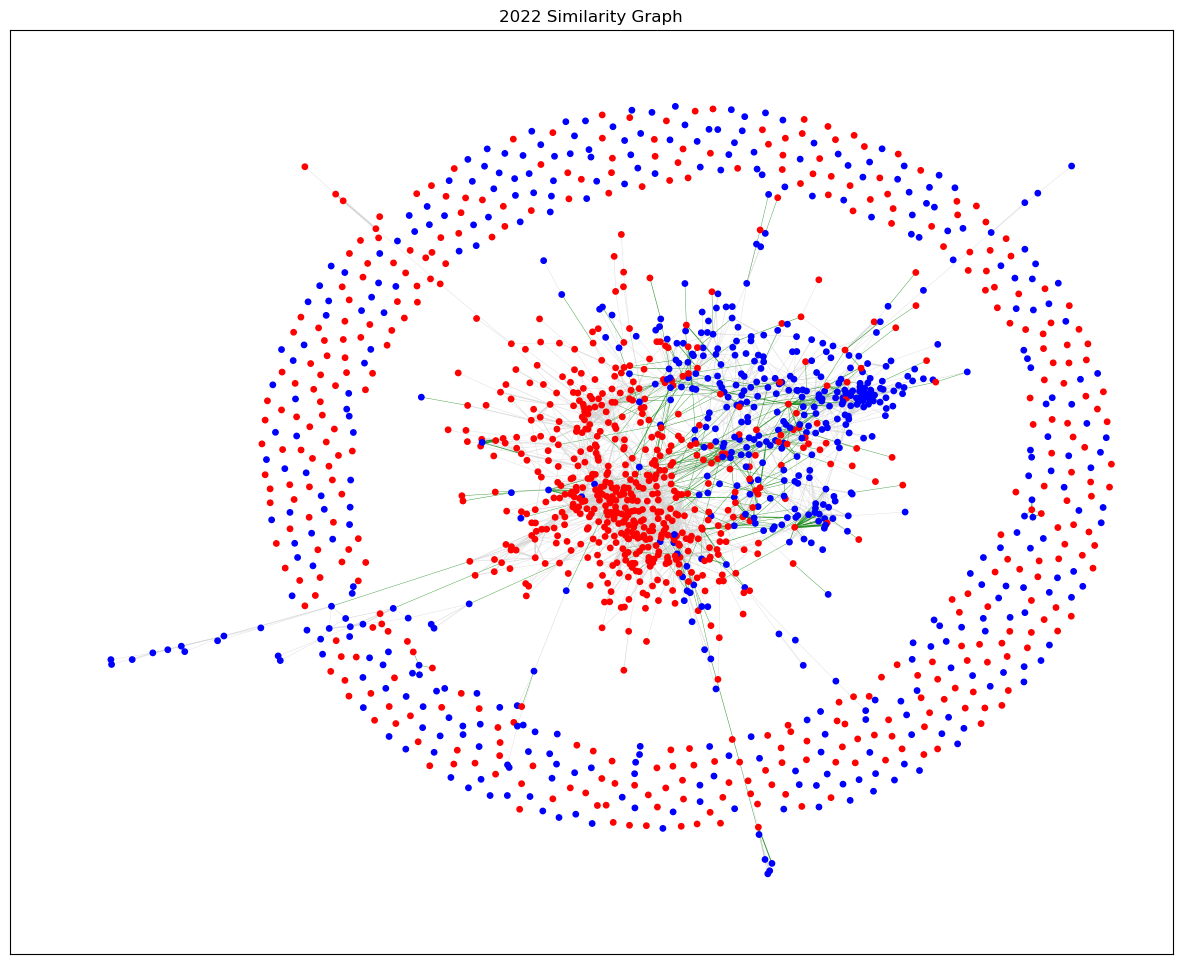

2022 LCC Similarity Graph:
Number of Nodes: 925
Number of Edges: 3333


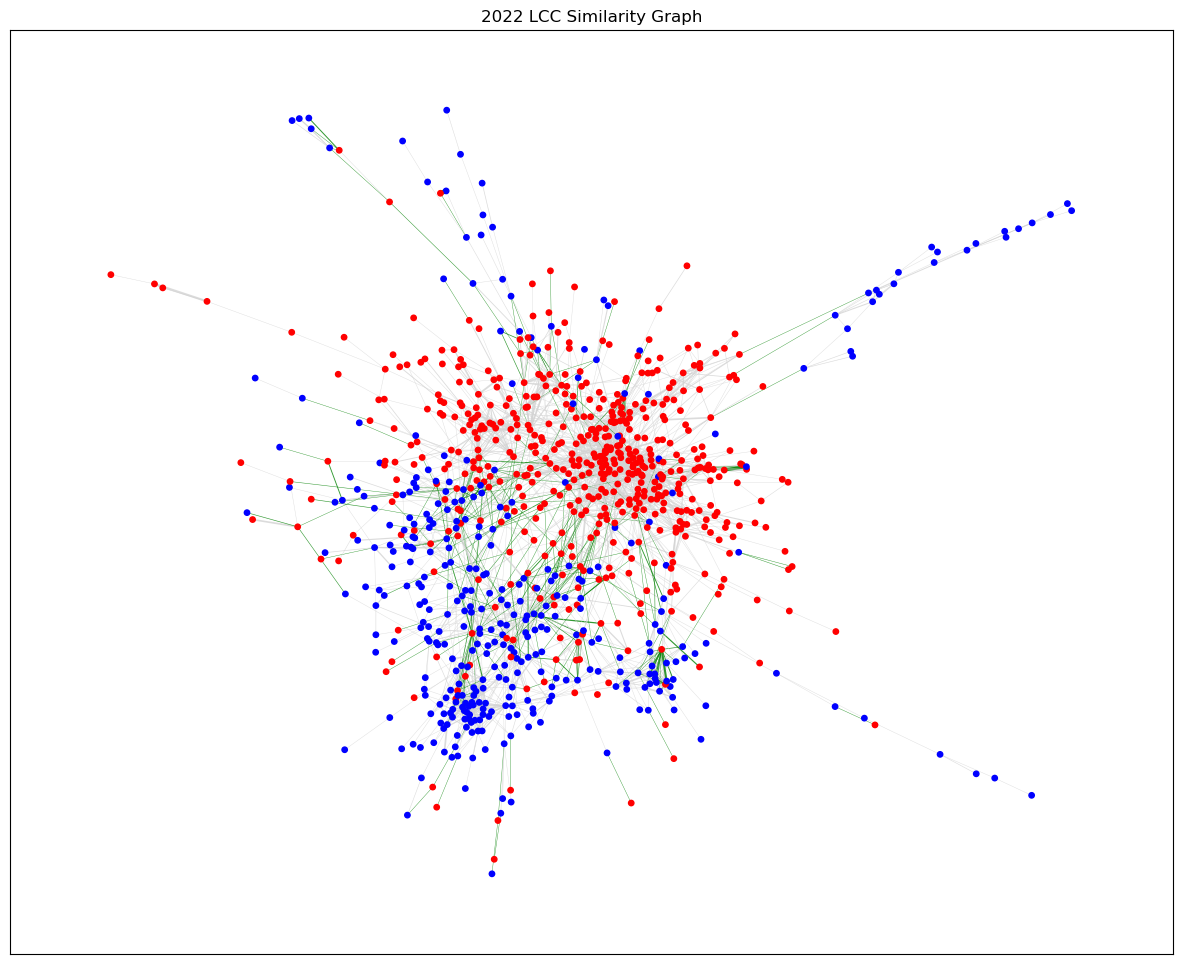

2022 Similarity Graph:
Number of Nodes: 1559
Number of Edges: 3375


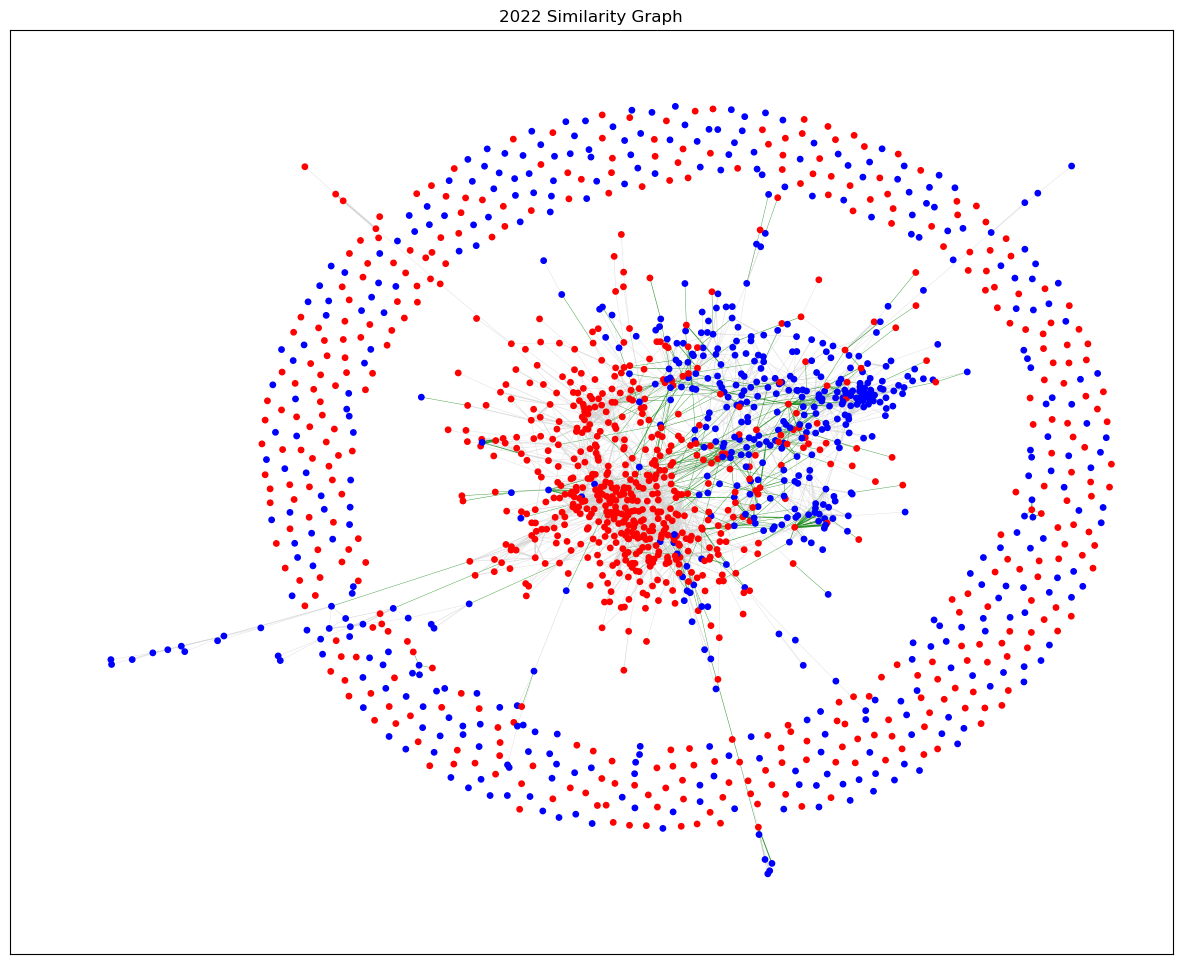

Most Similar Candidates:
Dems: Jamie Cheney / John S Selker
Reps: J. Michael Davisson / Wesley Hunt

2022 LCC Similarity Graph:
Number of Nodes: 925
Number of Edges: 3333


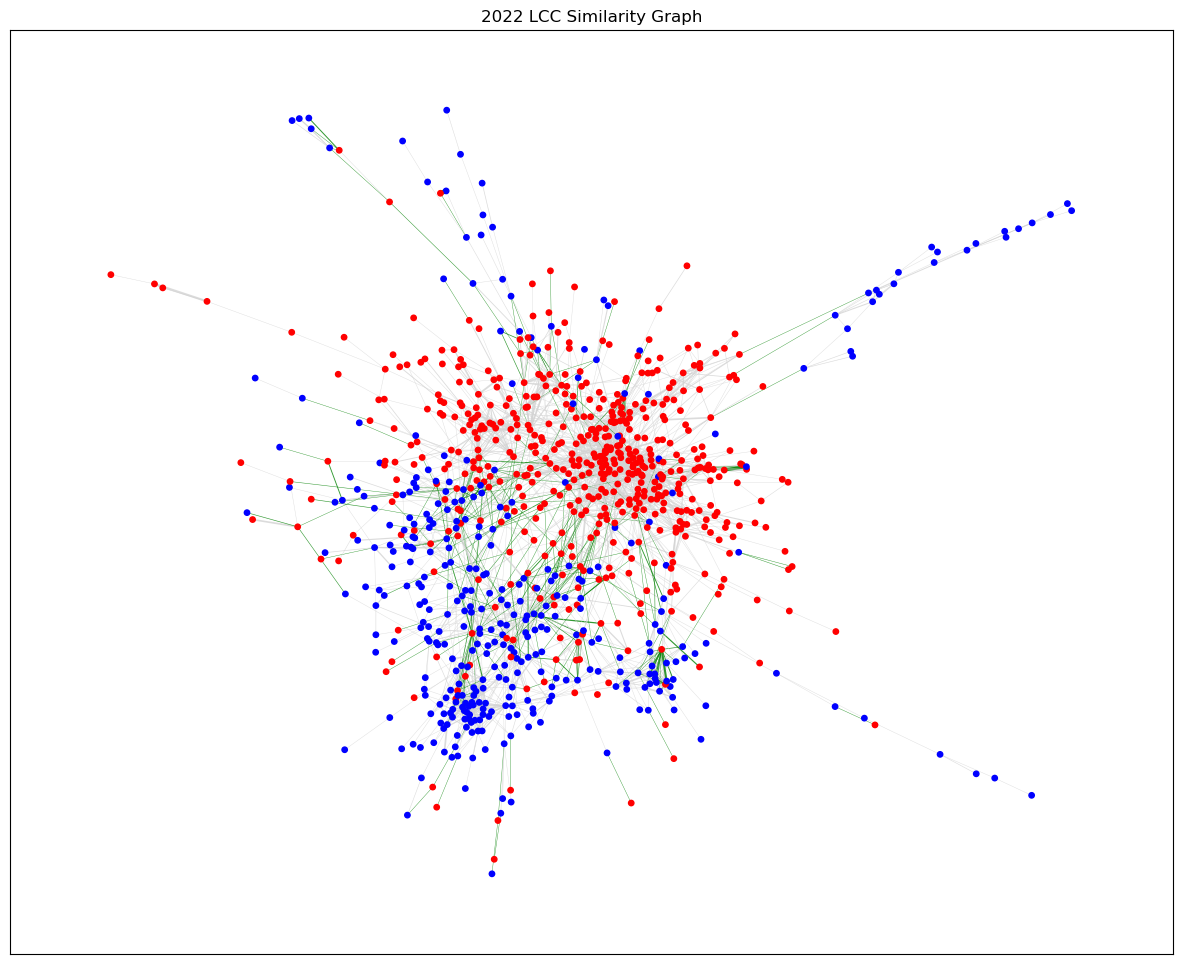

Most Similar Candidates:
Dems: Jamie Cheney / John S Selker
Reps: J. Michael Davisson / Wesley Hunt




In [ ]:
# full graph 2022
most_sim_2022 = create_graph(G_2022, "2022 Similarity Graph")
most_sim_text_2022, most_sim_names_2022 = get_candidate_platform_text(most_sim_2022, G_2022, all_data_2022)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2022[0], "/",  most_sim_names_2022[1])
print("Reps:", most_sim_names_2022[2], "/",  most_sim_names_2022[3])
print()

# LCC graph 2022
components_2022 = nx.connected_components(G_2022)
G_2022_LCC = G_2022.subgraph(max(components_2022, key=len)).copy()

most_sim_2022_LCC = create_graph(G_2022_LCC, "2022 LCC Similarity Graph")
most_sim_text_2022_LCC, most_sim_names_2022_LCC = get_candidate_platform_text(most_sim_2022_LCC, G_2022_LCC, all_data_2022)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2022_LCC[0], "/",  most_sim_names_2022_LCC[1])
print("Reps:", most_sim_names_2022_LCC[2], "/",  most_sim_names_2022_LCC[3])
print("\n")

## Basic Stats

In [166]:
stats_data = {
    'Graph': ['G_2018', 'G_2020', 'G_2022'],
    'Num Nodes': [
        len(G_2018.nodes),
        len(G_2020.nodes),
        len(G_2022.nodes)
    ],
    'Num Edges': [
        len(G_2018.edges),
        len(G_2020.edges),
        len(G_2022.edges)
    ],
    'Density': [
        nx.density(G_2018),
        nx.density(G_2020),
        nx.density(G_2022)
    ],
    'Assortativity by Party': [
        nx.attribute_assortativity_coefficient(G_2018, "cand_party"),
        nx.attribute_assortativity_coefficient(G_2020, "cand_party"),
        nx.attribute_assortativity_coefficient(G_2022, "cand_party")
    ]
}

stats_df = pd.DataFrame(stats_data)
print(stats_df)

    Graph  Num Nodes  Num Edges   Density  Assortativity by Party
0  G_2018       1499       7426  0.006614                0.460811
1  G_2020       1449       4977  0.004744                0.488169
2  G_2022       1559       3375  0.002779                0.740557


In [167]:


# Find the largest connected component
largest_component = max(nx.connected_components(G_2018), key=len)

# Create a subgraph of the largest connected component
subgraph = G_2018.subgraph(largest_component)

# Calculate the diameter of the subgraph
diameter = nx.diameter(subgraph)

print(f"Diameter of the largest connected component: {diameter}")



KeyboardInterrupt: 

## Edge Distributions

<BarContainer object of 144 artists>

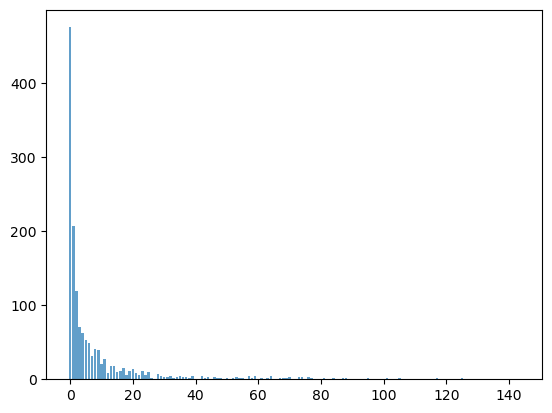

In [ ]:
l = [G_2018.degree(u) for u in G_2018.nodes()]

count = [0]*(max(l)+1)
for i in range(max(l)+1):
  count[i] = l.count(i)

plt.bar(range(max(l)+1), count, align='center', alpha=0.7, label='Observed Degree Distribution')

In [ ]:


%pip install powerlaw
import powerlaw

fit = powerlaw.Fit(l, discrete=True) # discrete=True for integer degree values
alpha2 = fit.power_law.alpha
xmin = fit.power_law.xmin

R, p = fit.distribution_compare('power_law', 'lognormal')
print(f"Power-law vs Lognormal: R={R}, p={p}")

Note: you may need to restart the kernel to use updated packages.
Calculating best minimal value for power law fit
Power-law vs Lognormal: R=-21.624456767771083, p=2.153543240332656e-05


Values less than or equal to 0 in data. Throwing out 0 or negative values


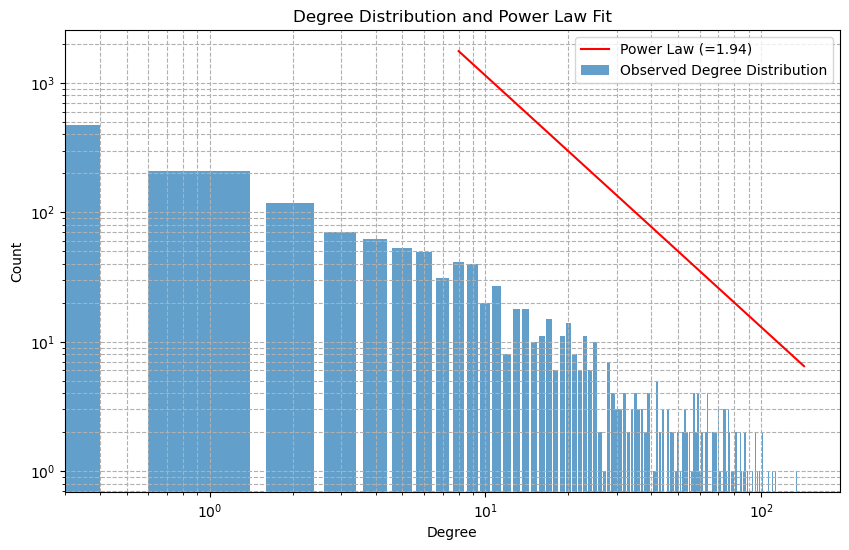

In [ ]:
# Plot the degree distribution as a bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(max(l)+1), count, align='center', alpha=0.7, label='Observed Degree Distribution')

# Add the powerlaw function to the plot
# Using the estimated alpha from cell zJlv0nOOyKlH
xmin = xmin # Assuming xmin is 1 based on previous cell
alpha = alpha2 # Using the calculated alpha value
x = np.arange(xmin, max(l) + 1)
# Avoid division by zero for x=0 if xmin is 0
if xmin == 0:
    x = np.arange(1, max(l) + 1)
    powerlaw_y = (x**-alpha) * (len(l) * np.mean(l) / sum(x**-alpha)) # Scale to match sum of degrees
else:
    powerlaw_y = (x**-alpha) * (len(l) * np.mean(l) / sum(x**-alpha)) # Scale to match sum of degrees

# Corrected label string for LaTeX
plt.plot(x, powerlaw_y, 'r-', label=f'Power Law (={alpha:.2f})')

plt.xlabel('Degree')
plt.ylabel('Count')
plt.title('Degree Distribution and Power Law Fit')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## Assortativity

In [ ]:
attr_assort = nx.attribute_assortativity_coefficient(G_2018, "cand_party")

attr_assort

0.460810505486414

I added this to the above statistics table as well.

## Degree and Betweenness Centrality

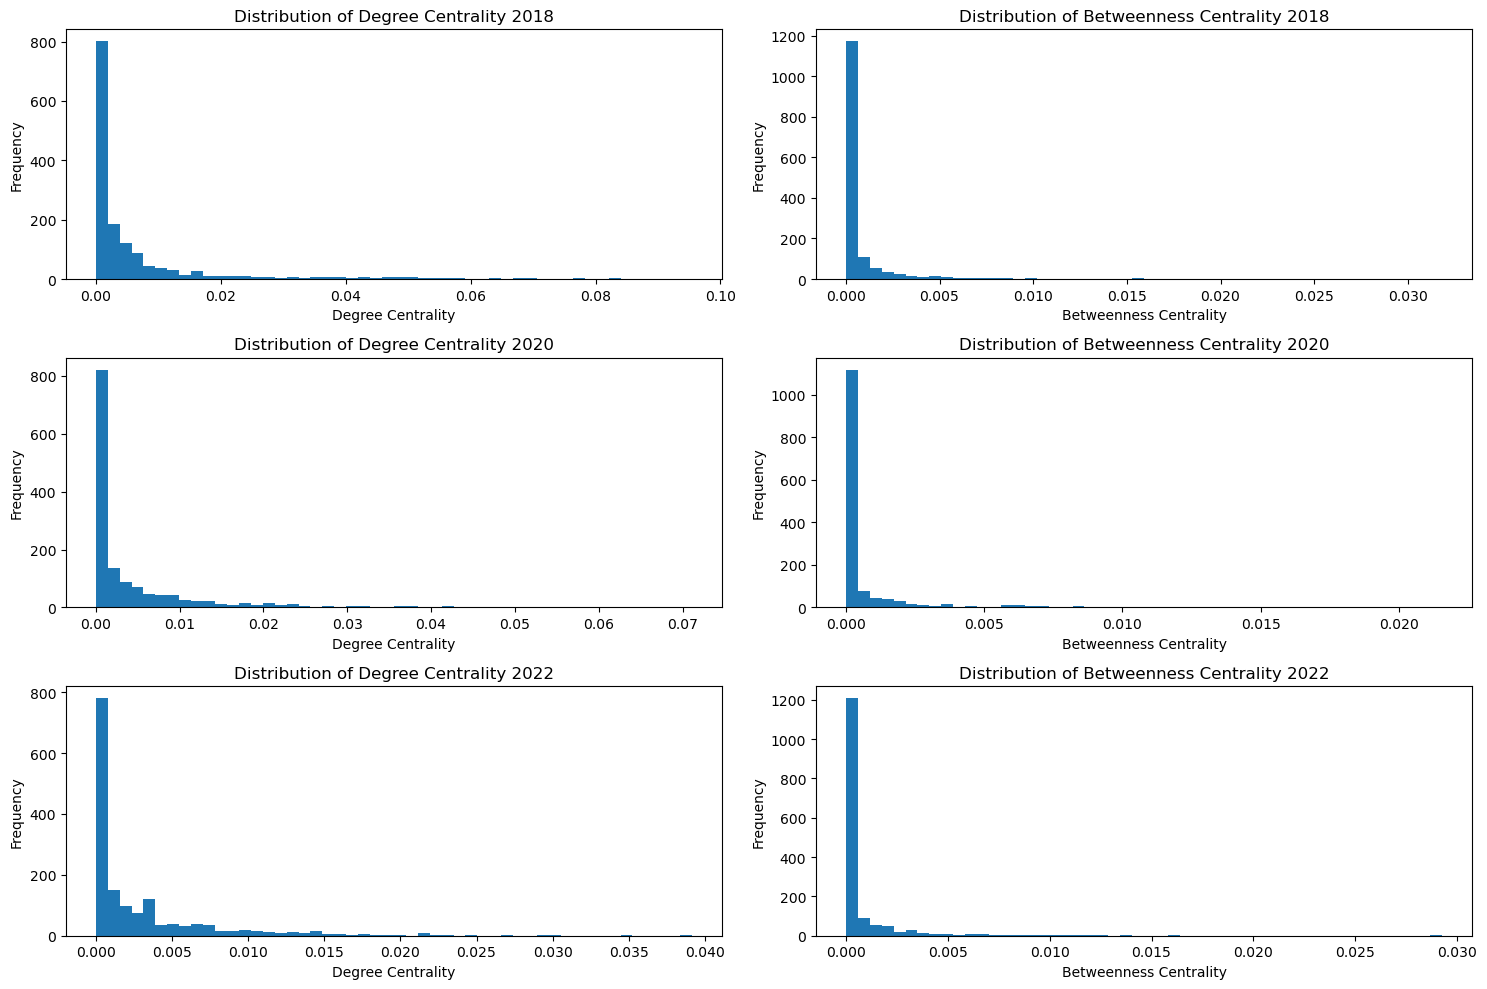

In [ ]:

# Calculate centrality measures
degree_centrality = nx.degree_centrality(G_2018)
# Betweenness centrality can be computationally expensive, consider sampling for large graphs
# Using the custom implementation from earlier for consistency, but will use a sample of nodes
# for the full graph or use the NetworkX implementation with k for approximation if needed.
# For now, let's use the built-in with k for approximation on the full graph
# betweenness_centrality = betweenness_centrality(G) # Using custom, but slow for full graph
betweenness_centrality = nx.betweenness_centrality(G_2018, k=100) # Using NetworkX with k=100 for approximation

# Create lists of centrality values for plotting
degree_values_2018 = list(degree_centrality.values())
betweenness_values_2018 = list(betweenness_centrality.values())

degree_centrality = nx.degree_centrality(G_2020)
betweenness_centrality = nx.betweenness_centrality(G_2020, k=100)

degree_values_2020 = list(degree_centrality.values())
betweenness_values_2020 = list(betweenness_centrality.values())

degree_centrality = nx.degree_centrality(G_2022)
betweenness_centrality = nx.betweenness_centrality(G_2022, k=100)

degree_values_2022 = list(degree_centrality.values())
betweenness_values_2022 = list(betweenness_centrality.values())


# Plot centrality distributions
plt.figure(figsize=(15, 10))

plt.subplot(3, 2, 1)
plt.hist(degree_values_2018, bins=50)
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality 2018')

plt.subplot(3, 2, 2)
plt.hist(betweenness_values_2018, bins=50)
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Betweenness Centrality 2018')

plt.subplot(3, 2, 3)
plt.hist(degree_values_2020, bins=50)
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality 2020')

plt.subplot(3, 2, 4)
plt.hist(betweenness_values_2020, bins=50)
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Betweenness Centrality 2020')

plt.subplot(3, 2, 5)
plt.hist(degree_values_2022, bins=50)
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality 2022')

plt.subplot(3, 2, 6)
plt.hist(betweenness_values_2022, bins=50)
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Betweenness Centrality 2022')

plt.tight_layout()
#plt.suptitle('Overall Figure Title', fontsize=16, fontweight='bold')
plt.show()


## Similarity Within Party

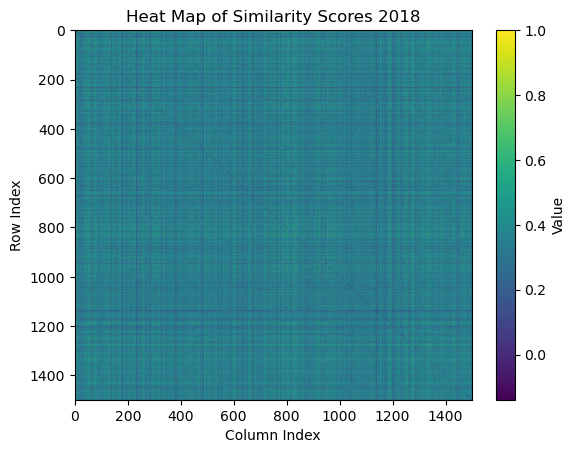

In [ ]:
plt.imshow(sim_scores_2018, cmap='viridis', aspect='auto')

# Add a colorbar for reference
plt.colorbar(label='Value')

# Add labels and title
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.title('Heat Map of Similarity Scores 2018')

# Show the plot
plt.show()



In [ ]:
np.shape(sim_scores_2018[(all_data_2018['cand_party']=='Republican'),:][:,(all_data_2018['cand_party']=='Republican')])

(631, 631)

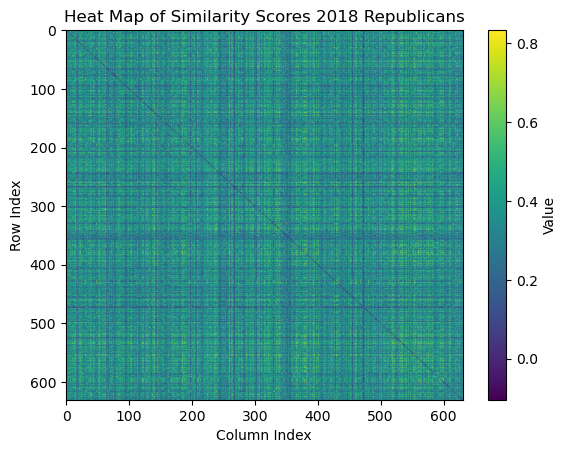

In [ ]:
plt.imshow(sim_scores_2018[(all_data_2018['cand_party']=='Republican'),:][:,(all_data_2018['cand_party']=='Republican')], aspect='auto')

# Add a colorbar for reference
plt.colorbar(label='Value')

# Add labels and title
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.title('Heat Map of Similarity Scores 2018 Republicans')

# Show the plot
plt.show()

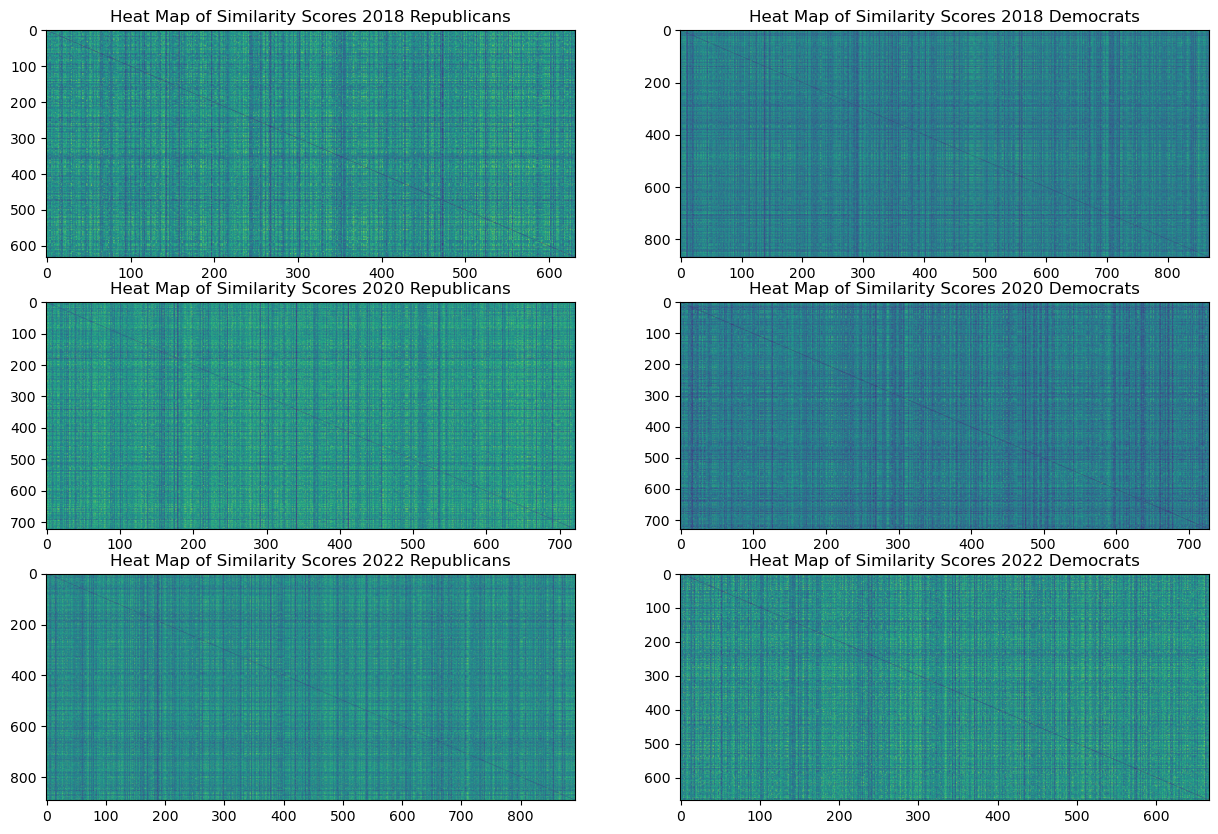

In [ ]:





plt.figure(figsize=(15, 10))

plt.subplot(3, 2, 1)
plt.imshow(sim_scores_2018[(all_data_2018['cand_party']=='Republican'),:][:,(all_data_2018['cand_party']=='Republican')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2018 Republicans')

plt.subplot(3, 2, 2)
plt.imshow(sim_scores_2018[(all_data_2018['cand_party']=='Democrat'),:][:,(all_data_2018['cand_party']=='Democrat')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2018 Democrats')

plt.subplot(3, 2, 3)
plt.imshow(sim_scores_2020[(all_data_2020['cand_party']=='Republican'),:][:,(all_data_2020['cand_party']=='Republican')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2020 Republicans')

plt.subplot(3, 2, 4)
plt.imshow(sim_scores_2020[(all_data_2020['cand_party']=='Democrat'),:][:,(all_data_2020['cand_party']=='Democrat')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2020 Democrats')

plt.subplot(3, 2, 5)
plt.imshow(sim_scores_2022[(all_data_2022['cand_party']=='Republican'),:][:,(all_data_2022['cand_party']=='Republican')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2022 Republicans')

plt.subplot(3, 2, 6)
plt.imshow(sim_scores_2022[(all_data_2022['cand_party']=='Democrat'),:][:,(all_data_2022['cand_party']=='Democrat')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2022 Democrats')

plt.show()

## Community Detection

In [ ]:

# Apply Girvan-Newman algorithm
communities_generator = co.girvan_newman(G_2018)

# Iterate to get a suitable partition (e.g., the first non-trivial partition)
# For larger graphs, iterating until modularity peaks or a certain number of communities is reached might be better.
# For this example, let's take the first partition found by the generator.

# Get the first partition
# The generator yields a tuple of frozensets, each frozenset is a community
# We'll take the first split (2 communities)

try:
    # Get communities for the first split
    first_partition = next(communities_generator)
    # Convert frozensets to sets for easier manipulation if needed
    communities_gn = [set(c) for c in first_partition]

    # If the first split is trivial (e.g., one huge community and many singletons), try to get the next split
    # However, for Girvan-Newman, it typically starts by splitting the graph into two large components.
    # For simplicity, we stick to the first partition initially.

    print(f"Initial number of communities found: {len(communities_gn)}")

    # Calculate modularity
    mod_gn = co.modularity(G_2018, communities_gn)

    # Determine number of communities
    num_communities = len(communities_gn)

    # Calculate size distribution
    community_sizes = [len(c) for c in communities_gn]

    print(f"\n--- Girvan-Newman Community Detection ---")
    print(f"Number of communities: {num_communities}")
    print(f"Community size distribution (first 10, sorted): {sorted(community_sizes, reverse=True)[:10]}")
    print(f"Modularity: {mod_gn:.4f}")

    # Create a mapping from node to color based on community
    node_colors = ['None'] * G_2018.number_of_nodes() # Initialize with 'None' or a default color
    color_map = plt.cm.get_cmap('tab20', num_communities)

    node_to_community_id = {}
    for i, comm in enumerate(communities_gn):
        for node in comm:
            node_to_community_id[node] = i

    # Assign colors based on community ID
    # Ensure all nodes in G are covered. Some nodes might be isolated and not part of any found community if `first_partition` is not exhaustive.
    # The Girvan-Newman typically provides a partition of all nodes.

    colors = [color_map(node_to_community_id.get(node, -1)) for node in G_2018.nodes()]

    # Visualize the communities
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G_2018, k=0.1, iterations=50) # Fruchterman-Reingold layout for better visualization
    nx.draw_networkx_nodes(G_2018, pos, node_color=colors, node_size=50, alpha=0.8)
    nx.draw_networkx_edges(G_2018, pos, alpha=0.1)
    plt.title("Girvan-Newman Community Detection")
    plt.axis('off')
    plt.show()

except StopIteration:
    print("Girvan-Newman generator did not yield any communities.")
except Exception as e:
    print(f"An error occurred: {e}")

KeyboardInterrupt: 

In [ ]:
largest_cc = max(nx.connected_components(G_2018), key=len)
main_component_subgraph = G_2018.subgraph(largest_cc)

# Apply Girvan-Newman algorithm
communities_generator = co.girvan_newman(main_component_subgraph)

# Iterate to get a suitable partition (e.g., the first non-trivial partition)
# For larger graphs, iterating until modularity peaks or a certain number of communities is reached might be better.
# For this example, let's take the first partition found by the generator.

# Get the first partition
# The generator yields a tuple of frozensets, each frozenset is a community
# We'll take the first split (2 communities)

try:
    # Get communities for the first split
    first_partition = next(communities_generator)
    # Convert frozensets to sets for easier manipulation if needed
    communities_gn = [set(c) for c in first_partition]

    # If the first split is trivial (e.g., one huge community and many singletons), try to get the next split
    # However, for Girvan-Newman, it typically starts by splitting the graph into two large components.
    # For simplicity, we stick to the first partition initially.

    print(f"Initial number of communities found: {len(communities_gn)}")

    # Calculate modularity
    mod_gn = co.modularity(main_component_subgraph, communities_gn)

    # Determine number of communities
    num_communities = len(communities_gn)

    # Calculate size distribution
    community_sizes = [len(c) for c in communities_gn]

    print(f"\n--- Girvan-Newman Community Detection ---")
    print(f"Number of communities: {num_communities}")
    print(f"Community size distribution (first 10, sorted): {sorted(community_sizes, reverse=True)[:10]}")
    print(f"Modularity: {mod_gn:.4f}")

    # Create a mapping from node to color based on community
    node_colors = ['None'] * main_component_subgraph.number_of_nodes() # Initialize with 'None' or a default color
    color_map = plt.cm.get_cmap('tab20', num_communities)

    node_to_community_id = {}
    for i, comm in enumerate(communities_gn):
        for node in comm:
            node_to_community_id[node] = i

    # Assign colors based on community ID
    # Ensure all nodes in G are covered. Some nodes might be isolated and not part of any found community if `first_partition` is not exhaustive.
    # The Girvan-Newman typically provides a partition of all nodes.

    colors = [color_map(node_to_community_id.get(node, -1)) for node in main_component_subgraph.nodes()]

    # Visualize the communities
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(main_component_subgraph, k=0.1, iterations=50) # Fruchterman-Reingold layout for better visualization
    nx.draw_networkx_nodes(main_component_subgraph, pos, node_color=colors, node_size=50, alpha=0.8)
    nx.draw_networkx_edges(main_component_subgraph, pos, alpha=0.1)
    plt.title("Girvan-Newman Community Detection")
    plt.axis('off')
    plt.show()

except StopIteration:
    print("Girvan-Newman generator did not yield any communities.")
except Exception as e:
    print(f"An error occurred: {e}")

KeyboardInterrupt: 